In [ ]:
import rioxarray as rio
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.ndimage import gaussian_filter

import matplotlib
import pyproj

from matplotlib.ticker import FuncFormatter

plt.style.use("aslak")
secpryr = 31556926  # seconds per year


def kmscale():
    formatter = FuncFormatter(lambda x, pos: f"{x/1000:.0f}")
    plt.gca().xaxis.set_major_formatter(formatter)
    plt.gca().yaxis.set_major_formatter(formatter)
    plt.xlabel("Easting (km)")
    plt.ylabel("Northing (km)")
    plt.gca().set_aspect("equal", "box")

In [ ]:
from density_core import DensityCore

S51 = DensityCore.load("_prepared_data/S5-1hxct_density_core.pkl")
S52 = DensityCore.load("_prepared_data/S5-2adj_density_core.pkl")
EG = DensityCore.load("_prepared_data/EGRIP_density_core.pkl")

import pandas as pd

flowline_S51 = pd.read_parquet("_prepared_data/S5-1hxct_backtrajectory.parquet")
flowline_S52 = pd.read_parquet("_prepared_data/S5-2adj_backtrajectory.parquet")
flowline_EG = pd.read_parquet("_prepared_data/EGRIP_backtrajectory.parquet")

flowlines = [flowline_S51, flowline_EG]
for ii in range(len(flowlines)):
    # downsample and order for modelling
    flowline = flowlines[ii]
    # keepers = flowline.t % (5 + 0 * (flowline.t / 200).astype(int)) == 0
    # flowline = flowline.loc[keepers]
    flowline.t = -flowline.t * 1.0
    flowlines[ii] = flowline.sort_values(by="t")

cores = [S51, EG]
cores[0]

In [ ]:
sites = {"EastGRIP": [EG.lat, EG.lon], "S5-1": [S51.lat, S51.lon]}  # , "S5-2": [S52.lat, S52.lon]}
mapproj = pyproj.Transformer.from_crs("epsg:4326", "epsg:3413")
for site in sites:
    sites[site] = mapproj.transform(*sites[site])
print(sites)

minx = 225000 + 5000
miny = -1570000 + 5000
maxx = 265000 + 5000
maxy = -1535000 + 5000

{'EastGRIP': (245693.1464142641, -1546180.0267532468), 'S5-1': (257025.86564058406, -1550170.9610600085)}


In [ ]:
bg = rio.open_rasterio("figures/bg_cog.tif")
bg = bg[:, ::5, ::5]
v = rio.open_rasterio(r"C:\Users\ag\HugeData\Greenland IV\MEaSUREs\M Multi-year IV mosaic v1\greenland_vel_mosaic250_vv_v1.tif")
v = v.squeeze("band")
v.data[v.data > 1e7] = 0

# ----------------
# smoothing = 4
# vx = rio.open_rasterio(r"C:\Users\ag\HugeData\Greenland IV\TSX/TerraSAR-X_vel_AWI_V0.2_vx.tif").squeeze("band")
# vy = rio.open_rasterio(r"C:\Users\ag\HugeData\Greenland IV\TSX/TerraSAR-X_vel_AWI_V0.2_vy.tif").squeeze("band")

vx = (
    rio.open_rasterio(r"C:\Users\ag\HugeData\Greenland IV\DTU-Space/greenland_iv_50m_s1_20191216_20200125_zwally21_winter_v1.0_vx.tif").squeeze(
        "time"
    )
    * 365
)
vy = (
    rio.open_rasterio(r"C:\Users\ag\HugeData\Greenland IV\DTU-Space/greenland_iv_50m_s1_20191216_20200125_zwally21_winter_v1.0_vy.tif").squeeze(
        "time"
    )
    * 365
)


vx.rio.write_crs("epsg:3413", inplace=True)
vy.rio.write_crs("epsg:3413", inplace=True)

smoothing = 250 / np.abs(vx.x[1] - vx.x[0]).values

vx = vx.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
vx.data = gaussian_filter(vx.data, sigma=smoothing)
vy = vy.rio.clip_box(minx=minx, miny=miny, maxx=maxx, maxy=maxy)
vy.data = gaussian_filter(vy.data, sigma=smoothing)
exx = vx.differentiate("x")
dvxdy = vx.differentiate("y")
dvydx = vy.differentiate("x")
eyy = vy.differentiate("y")
exy = 0.5 * (dvxdy + dvydx)

ezz = -exx - eyy
exz = 0
eyz = 0
e_e = np.sqrt(0.5 * (exx * exx + eyy * eyy + ezz * ezz + 2 * (exy**2 + exz**2 + eyz**2)))

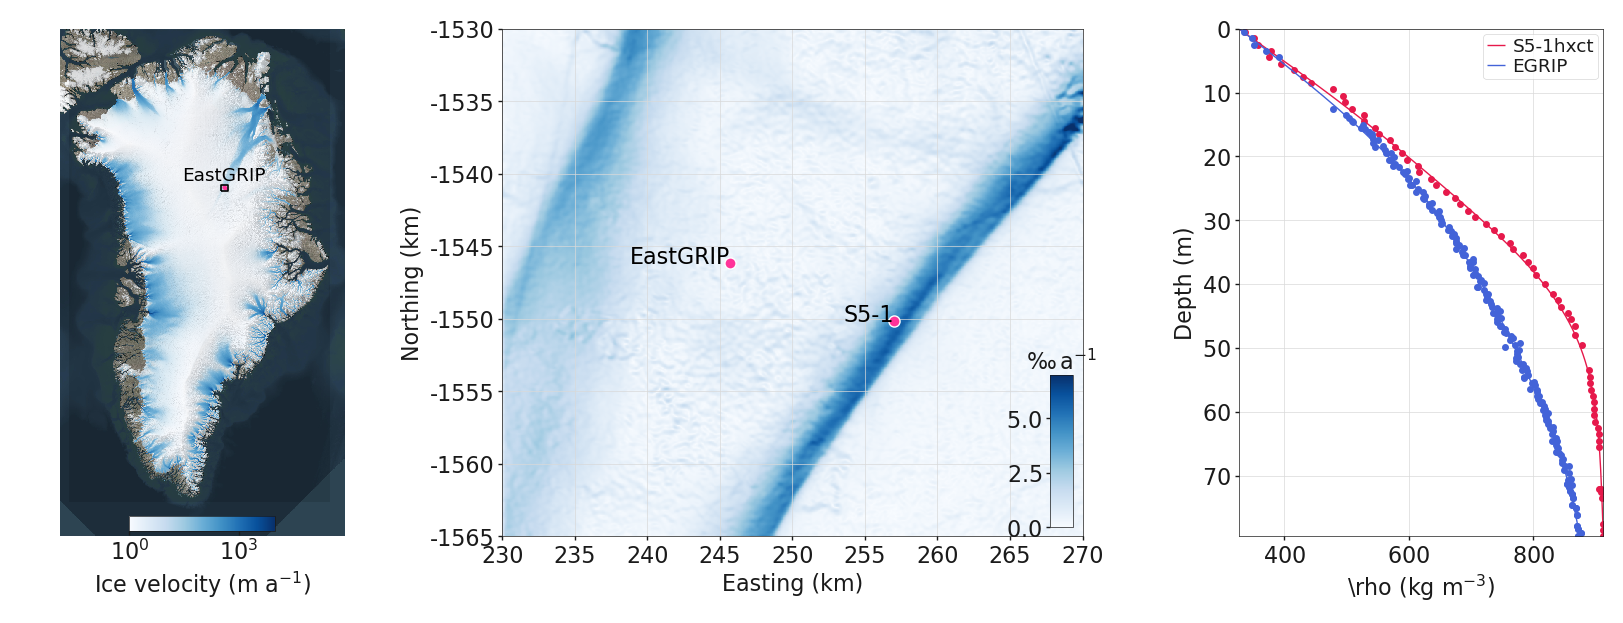

In [9]:
plt.style.use("aslak")

fig, ax = plt.subplot_mosaic("abbc", figsize=[8, 3], layout="constrained", dpi=200)

plt.sca(ax["a"])
if True:
    bg.plot.imshow()
    hv = v.plot.imshow(
        cmap="Blues",
        vmin=1,
        vmax=10000,
        alpha=(np.tanh((v - 50) / 40) / 2.2 + 0.5) * ~np.isnan(v),
        add_colorbar=False,
        norm=matplotlib.colors.LogNorm(),
    )
plt.title("")
plt.axis("off")
plt.axis("equal")
for site, xy in sites.items():
    plt.plot(xy[0], xy[1], ".", color="#FF3399", markersize=1)
plt.plot([minx, maxx, maxx, minx, minx], [miny, miny, maxy, maxy, miny], "k-", lw=0.6)
plt.text((minx + maxx) / 2, maxy, "EastGRIP", ha="center", va="bottom", fontsize="small")


# plt.plot(sites["EGRIP"][0], sites["EGRIP"][1], ".")
# cax = inset_axes(ax["a"], width="60%", height="5%", loc=8)
cax = ax["a"].inset_axes([0.3, 0.01, 0.4, 0.03])
plt.colorbar(label="Ice velocity (m a$^{-1}$)", cax=cax, orientation="horizontal", mappable=hv)


plt.sca(ax["b"])
he = (e_e * 1000).plot.imshow(cmap="Blues", add_colorbar=False, vmax=7, vmin=0)
# plt.grid(color="k", linewidth=0.5, alpha=0.05)
plt.grid("off")
plt.xlim(minx, maxx)
plt.ylim(miny, maxy)
kmscale()
for site, xy in sites.items():
    plt.plot(xy[0], xy[1], "o", markerfacecolor="#FF3399", markersize=4, markeredgecolor="w", markeredgewidth=0.5)
    plt.text(xy[0], xy[1], site, ha="right")
plt.title("")
ax["b"].set_aspect("equal", adjustable="box")


cax = inset_axes(ax["b"], width="4%", height="30%", loc=4)
plt.colorbar(cax=cax, orientation="vertical", mappable=he)
cax.set_title("$\\mathrm{‰\\,a^{-1}}$")
cax.yaxis.set_ticks_position("left")
cax.yaxis.set_label_position("left")


plt.sca(ax["c"])
for core in cores:
    core.plot(lw=0.5, show_raw=True)
plt.legend()
plt.xlabel("\\rho (kg m$^{-3}$)")
plt.ylabel("Depth (m)")

import settings

plt.savefig(f"{settings.figure_folder}/fig1_sitedata.png", dpi=300)

In [10]:
from dataclasses import asdict

asdict(core).keys()

dict_keys(['site_name', 'lat', 'lon', 'T', 'bdot', 'e1', 'e2', '_z', '_rho', '_raw_z', '_raw_rho', '_drho_dz', '_overburden'])